## Install Libraries

In [1]:
!pip install langchain langchain-community langchain-huggingface
!pip install sentence-transformers transformers accelerate python-dotenv
!pip install faiss-cpu wikipedia pypdf nltk chromadb cohere tiktoken jq pandas unstructured
!pip install langchain_community langchain_text_splitters langchain-chroma chromadb langchain_huggingface
!pip install wikipedia
!pip install langchain_core langchain-classic
!pip install langchain_classic
!pip install dotenv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.28
    Uninstalling langchain-core-1.2.28:
      Successfully uninstalled langchain-core-1.2.28
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>

## Load All Pdfs Using PyPDFDirectory

In [2]:
from langchain_community.document_loaders import PyPDFDirectoryLoader

loader = PyPDFDirectoryLoader(
    "/kaggle/input/datasets/ehabashraf/ml-directory"
)

llm_data = loader.load()

/tmp/ipykernel_58/2506713329.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFDirectoryLoader


In [28]:
llm_data[110].page_content

'+\n◼ Semi-supervised machine learning is a combination of supervised and unsupervised machine\nlearning methods.\n◼ In semi-supervised learning, an algorithm learns from a dataset that includes both labeled and\nunlabeled data, usually mostly unlabeled.\nSemi-supervised Learning\nJanuary 17, 2022\n44\nWhy is Semi-Supervised Machine Learning important?\n◼ When you don’t have enough labeled\ndata to produce an accurate model and\nyou don’t have the ability or resources to\nget more, you can use semi-supervised\ntechniques to increase the size of your\ntraining data.\n◼ You can use a semi-supervised learning \nalgorithm to label the data, and retrain the \nmodel with the newly labeled dataset\nThere is no way to verify that the algorithm produced labels that\nare 100% accurate, resulting in less trustworthy outcomes than\ntraditional supervised techniques.\nhttps://www.datarobot.com/wiki/semi-supervised-machine-learning/'

## Let's Make It Advanced by WikipediaLoader

In [2]:
from langchain_community.document_loaders import WikipediaLoader
import wikipedia
#for environment to make it run
wikipedia.set_user_agent("MyLangChainBot/1.0 (ehab44221@gmail.com)")

topics = [
    "Artificial Intelligence",
    "Machine Learning",
    "Deep Learning",
    "Generative Artificial Intelligence",
    "Large Language Model",
    "Natural Language Processing",
    "Computer Vision",
    "Reinforcement Learning",
    "Retrieval-Augmented Generation",
    "MLOps",
    "Data Science",
    "Neural Network",
    "Transformer (deep learning architecture)",
    "Prompt Engineering",
    "Agentic AI"
]

docs = []

for topic in topics:
    loader = WikipediaLoader(
        query=topic,
        load_max_docs=2,
        doc_content_chars_max=100000
    )

    docs.extend(loader.load())

print(f"Loaded {len(docs)} documents")

/tmp/ipykernel_58/4173326419.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WikipediaLoader


Loaded 30 documents


## Prepare Documents and MetaData To Pass Them In Splitter 

In [3]:
documents = [
    doc.page_content
    for doc in docs #replace docs with llm_data if you want to usen your pdfs directory
]
documents[20]


'Data science is an interdisciplinary academic field that uses statistics, scientific computing, scientific methods, processing, scientific visualization, algorithms, coding (like Python, SQL, and R), and systems to extract or extrapolate knowledge from potentially noisy, structured, or unstructured data. A data scientist is a professional who creates programming code and combines it with statistical knowledge to summarize data.\n\n\n== Scope of data science ==\nData science plays a critical role in modern decision-making by enabling organizations to extract actionable insights from large and complex datasets.\nData science also integrates domain knowledge from the underlying application domain (e.g., natural sciences, information technology, and medicine). Data science is multifaceted and can be described as a science, a research paradigm, a research method, a discipline, a workflow, and a profession.\nData science is "a concept to unify statistics, data analysis, informatics, and the

In [4]:
from pathlib import Path

metadatas = [
    {
        "file_name": Path(doc.metadata["source"]).stem
    }
    for doc in docs # #replace docs with llm_data if you want to usen your pdfs directory
]
metadatas

[{'file_name': 'Artificial_intelligence'},
 {'file_name': 'Artificial_general_intelligence'},
 {'file_name': 'Machine_learning'},
 {'file_name': 'Attention_(machine_learning)'},
 {'file_name': 'Deep_learning'},
 {'file_name': 'Transformer_(deep_learning)'},
 {'file_name': 'Generative_AI'},
 {'file_name': 'Hallucination_(artificial_intelligence)'},
 {'file_name': 'Large_language_model'},
 {'file_name': 'List_of_large_language_models'},
 {'file_name': 'Natural_language_processing'},
 {'file_name': 'Natural_language'},
 {'file_name': 'Computer_vision'},
 {'file_name': 'Computer_vision_syndrome'},
 {'file_name': 'Reinforcement_learning'},
 {'file_name': 'Deep_reinforcement_learning'},
 {'file_name': 'Retrieval-augmented_generation'},
 {'file_name': 'Prompt_engineering'},
 {'file_name': 'MLOps'},
 {'file_name': 'Artificial_intelligence_engineering'},
 {'file_name': 'Data_science'},
 {'file_name': 'List_of_data_science_software'},
 {'file_name': 'Neural_network'},
 {'file_name': 'Neural_netw

## Splitter Using NLTK and HUGGIN FACE

In [5]:
# import Libraries
from langchain_text_splitters import NLTKTextSplitter
import nltk
from langchain_huggingface import HuggingFaceEmbeddings
from transformers import AutoTokenizer,AutoModelForMultimodalLM
nltk.download('punkt')

# splitter Using Tokenizer From Hugging Face
model_id = "stabilityai/stablelm-tuned-alpha-3b"
tokenizer = AutoTokenizer.from_pretrained(model_id)
text_splitter = NLTKTextSplitter.from_huggingface_tokenizer(
    tokenizer,
    chunk_size=300,
    chunk_overlap=50
)
# Use the Splitter and Pass Documnets and MetaData 
tokens_chunks = text_splitter.create_documents(
    documents,
    metadatas=metadatas
)


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


config.json:   0%|          | 0.00/606 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/264 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Created a chunk of size 374, which is longer than the specified 300
Created a chunk of size 509, which is longer than the specified 300
Created a chunk of size 327, which is longer than the specified 300
Created a chunk of size 347, which is longer than the specified 300
Created a chunk of size 404, which is longer than the specified 300
Created a chunk of size 322, which is longer than the specified 300
Created a chunk of size 560, which is longer than the specified 300
Created a chunk of size 345, which is longer than the specified 300
Created a chunk of size 315, which is longer than the specified 300
Created a chunk of size 403, which is longer than the specified 300
Created a chunk of size 529, which is longer than the specified 300
Created a chunk of size 716, which is longer than the specified 300
Created a chunk of size 603, which is longer than the specified 300
Created a chunk of size 309, which is longer than the specified 300
Created a chunk of size 991, which is longer tha

## Create Embedding Using Hugging Face

In [6]:
# embeddings
embedding_llm = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Create Vector DataBase Using Chroma

In [7]:
from langchain_chroma import Chroma

# vector database
save_to_dir = "/kaggle/working/ML_chroma_db"
vector_db = Chroma.from_documents(
    tokens_chunks,
    embedding_llm,
    persist_directory=save_to_dir
)

## Using Chains to Generate the Final Answer

#### QnA Chain | Stuff

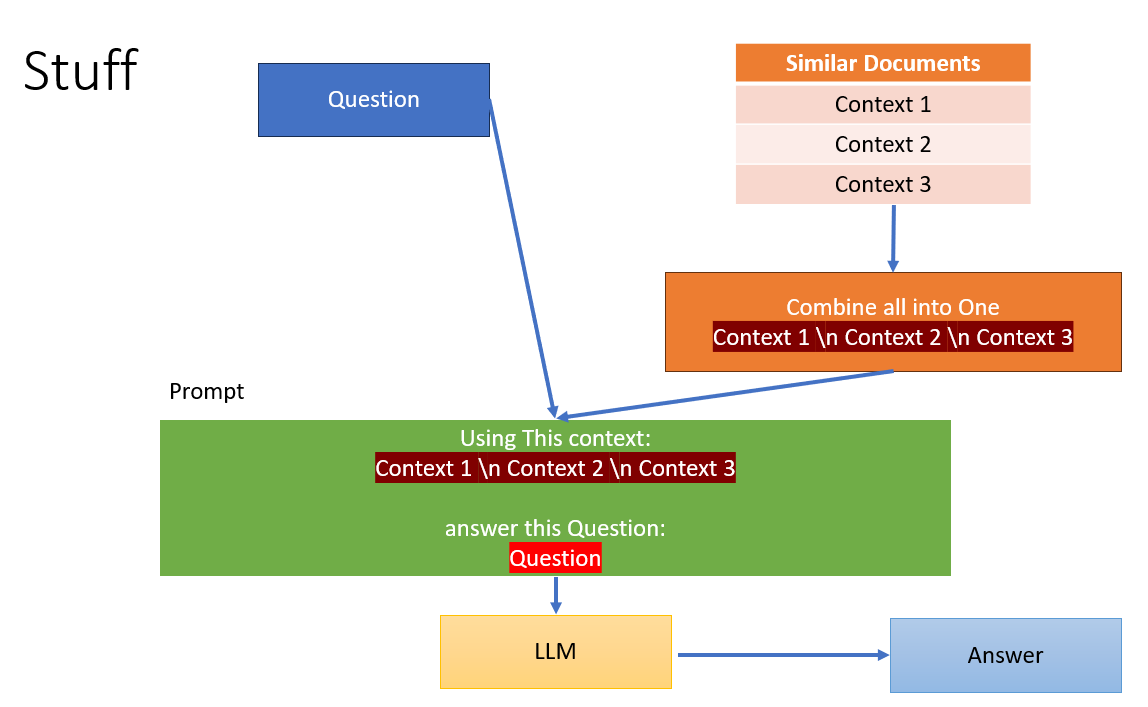

## Login Using HuggingFace Token

In [8]:
from huggingface_hub import notebook_login
notebook_login()

In [9]:
from langchain_classic.chains.question_answering import load_qa_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import PromptTemplate
from transformers import pipeline,AutoModelForQuestionAnswering,AutoModelForSeq2SeqLM,AutoModelForCausalLM
from langchain_huggingface import HuggingFacePipeline
import torch
from dotenv import dotenv_values


In [10]:
env_values = dotenv_values("./app.env")
openai_api_key = env_values['HF-TOKEN']

model_id = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(
    model_id,  
    token=openai_api_key

)


model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.bfloat16, # Efficient memory usage
    device_map="auto",           # Automatically uses GPU if available)
    token=openai_api_key

)
hf_pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=500,          # Keeps the answer short and crisp
    temperature=0.9,            # Lower temperature makes it strict and factual
    return_full_text=False,     # CRUCIAL: Stops LLaMA from printing the input prompt again
    pad_token_id=tokenizer.eos_token_id
)

llm = HuggingFacePipeline(
    pipeline=hf_pipe
)


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


## Using Buffer Window Memory 


In [11]:
from langchain_classic.memory import ConversationBufferMemory
memory = ConversationBufferMemory(
    memory_key="chat_history",
    return_messages=False
)

/tmp/ipykernel_58/2738832882.py:2: LangChainDeprecationWarning: The class `ConversationBufferMemory` was deprecated in LangChain 0.3.1 and will be removed in 2.0.0. Use `langchain.agents.create_agent` instead. For agents that need to remember prior interactions, use `create_agent` with checkpointing or the `Store` API. See https://docs.langchain.com/oss/python/langchain/short-term-memory and https://docs.langchain.com/oss/python/langchain/long-term-memory
  memory = ConversationBufferMemory(


## Making the Prompt

In [12]:
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

qna_template = """
You are an AI Knowledge Assistant.

Use the conversation history and provided context
to answer the user's question.

If the answer cannot be found in the context,
respond exactly:

NO ANSWER IS AVAILABLE

====================
Conversation History:
{chat_history}

====================
Context:
{context}

====================
Question:
{question}

====================
Answer:
"""

qna_prompt = PromptTemplate(
    template=qna_template,
     input_variables=[
        "chat_history",
        "context",
        "question"
    ],
    verbose=True
)

stuff_chain = load_qa_chain(llm, chain_type="stuff", prompt=qna_prompt)

/tmp/ipykernel_58/962121066.py:40: LangChainDeprecationWarning: The function `load_qa_chain` was deprecated in LangChain 0.2.13 and will be removed in 2.0.0. Use `langchain.agents.create_agent` instead. Build new RAG flows with `create_agent` and a retrieval tool. See https://docs.langchain.com/oss/python/langchain/rag
  stuff_chain = load_qa_chain(llm, chain_type="stuff", prompt=qna_prompt)


In [13]:
def ask_question(question):

    # Retrieve relevant chunks
    similar_docs = vector_db.similarity_search(
        question,
        k=5
    )

    # Previous conversation
    chat_history = memory.buffer

    # Generate answer
    result = stuff_chain.invoke(
        {
            "input_documents": similar_docs,
            "question": question,
            "chat_history": chat_history
        }
    )

    answer = result["output_text"]

    # Save memory
    memory.save_context(
        {"input": question},
        {"output": answer}
    )

    # Sources
    sources = sorted(
        {
            doc.metadata.get(
                "file_name",
                "Unknown"
            )
            for doc in similar_docs
        }
    )

    return answer, sources

In [ ]:
while True:

    question = input("\nwhat do you want to ask about: ")

    if question.lower() in [
        "exit",
        "quit",
        "bye"
    ]:
        break

    answer, sources = ask_question(
        question
    )

    print("\nAssistant:")
    print(answer)

    print("\nSources:")
    for source in sources:
        print("-", source)


what do you want to ask about:  what is Agentic Ai Mean ?


Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Assistant:
Agentic AI means a class of intelligent agents that can pursue goals, use tools, and take actions with varying degrees of autonomy. They typically operate within human-defined objectives, constraints, and available tools. Their control flow is often driven by large language models (LLMs). Agent systems may include memory components, planning logic, tool interfaces, and orchestration software for coordinating agent components. Common applications of AI agents include task automation, where they can book travel plans based on user prompts. Companies like Google, Microsoft, and AWS offer platforms for deploying pre-built AI agents. Some protocols are also used to connect agents to external applications. The Agentic AI Foundation (AAIF) was formed in December 2025 by the Linux Foundation with the goal of ensuring agentic AI evolves transparently and collaboratively.

Sources:
- AI_agent
- Artificial_general_intelligence
- Artificial_intelligence



what do you want to ask about:  nice is this will for Ai Engineer Carer


Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Assistant:
NO ANSWER IS AVAILABLE

Sources:
- Artificial_general_intelligence
- Artificial_intelligence
- Artificial_intelligence_engineering



what do you want to ask about:  well compare between it and ml


Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Assistant:
Agentic AI refers to a class of intelligent agents that can pursue goals, utilize tools, and make actions with varying levels of autonomy. These agents typically work under predefined objectives, constraints, and available resources. They employ mechanisms like large language models (LLMs) to guide their decision-making processes.

In contrast, Machine Learning (ML) is a broader field concerned with algorithms that enable computers to learn from data without being explicitly programmed. ML techniques involve creating predictive models using patterns discovered in historical data. It includes various methods like supervised learning, unsupervised learning, reinforcement learning, and others, depending on the specific problem at hand.

While ML is fundamental to modern AI, it does not inherently possess the same level of autonomy and capability as Agentic AI. ML models rely heavily on pre-existing datasets and rules set by humans, whereas Agentic AI can autonomously adapt to 

In [17]:
# similar_docs[0].page_content

'Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed.\n\nAdvances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\n\nStatistics and mathematical optimisation methods compose the foundations of machine learning.\n\nData mining is a related field of study, focusing on exploratory data analysis (EDA) through unsupervised learning.\n\nFrom a theoretical viewpoint, probably approximately correct learning provides a mathematical and statistical framework for describing machine learning.\n\nMost traditional machine learning and deep learning algorithms can be described as empirical risk minimisation under this framework.\n\n== History ==\n\nThe term machine learning was coined in 19

In [18]:
# answer = stuff_chain.invoke(
#     {
#         "input_documents": similar_docs,
#         "question": question
#     },
# )
# # 
# print(answer["output_text"])


Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Machine learning is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data. It involves creating models that can make predictions or decisions without explicit programming. Advances in deep learning have particularly improved performance in this area. Statistics and mathematical optimization methods form the foundational basis of machine learning.


In [19]:
# print(answer["input_documents"][3].metadata)

{'file_name': 'Artificial_intelligence'}
